<a href="https://colab.research.google.com/github/0Xemin/diabetes-risk-classification/blob/main/Diabet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
sample_sub=pd.read_csv('sample_submission.csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [5]:
train.shape

(700000, 26)

In [6]:
object_cols=[col for col in train.columns if train[col].dtype=='O']

In [7]:
for col in object_cols:
  print(f'unique values : in {col.upper()}')
  print('\n',train[col].unique())
  print('=' * 25)

unique values : in GENDER

 ['Female' 'Male' 'Other']
unique values : in ETHNICITY

 ['Hispanic' 'White' 'Asian' 'Black' 'Other']
unique values : in EDUCATION_LEVEL

 ['Highschool' 'Graduate' 'Postgraduate' 'No formal']
unique values : in INCOME_LEVEL

 ['Lower-Middle' 'Upper-Middle' 'Low' 'Middle' 'High']
unique values : in SMOKING_STATUS

 ['Current' 'Never' 'Former']
unique values : in EMPLOYMENT_STATUS

 ['Employed' 'Retired' 'Student' 'Unemployed']


In [8]:
def unique_values():
  for col in object_cols:
    print (f'unique values  : in {col.upper()}')
    print('\n', train[col].value_counts())
    print('==============================')

In [9]:
unique_values()

unique values  : in GENDER

 gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
unique values  : in ETHNICITY

 ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
unique values  : in EDUCATION_LEVEL

 education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
unique values  : in INCOME_LEVEL

 income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64
unique values  : in SMOKING_STATUS

 smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64
unique values  : in EMPLOYMENT_STATUS

 employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


Text(0.5, 1.0, 'Corelation Heatmap')

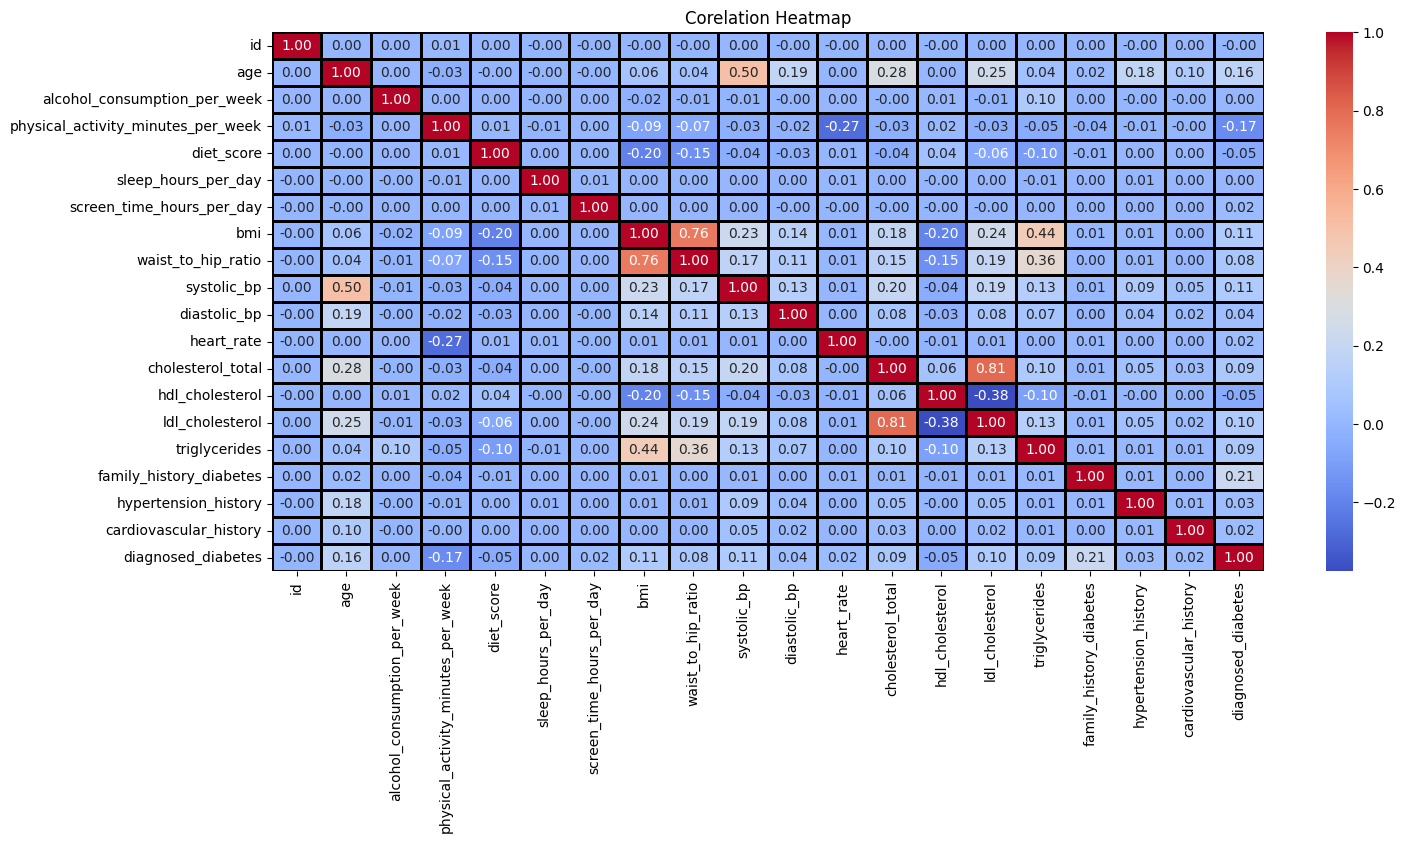

In [10]:
figsize = plt.figure(figsize=(16,7))
sns.heatmap(train.corr(numeric_only = True), annot = True , cmap='coolwarm',linewidth=1,linecolor='black', fmt='.2f')
plt.title('Corelation Heatmap')

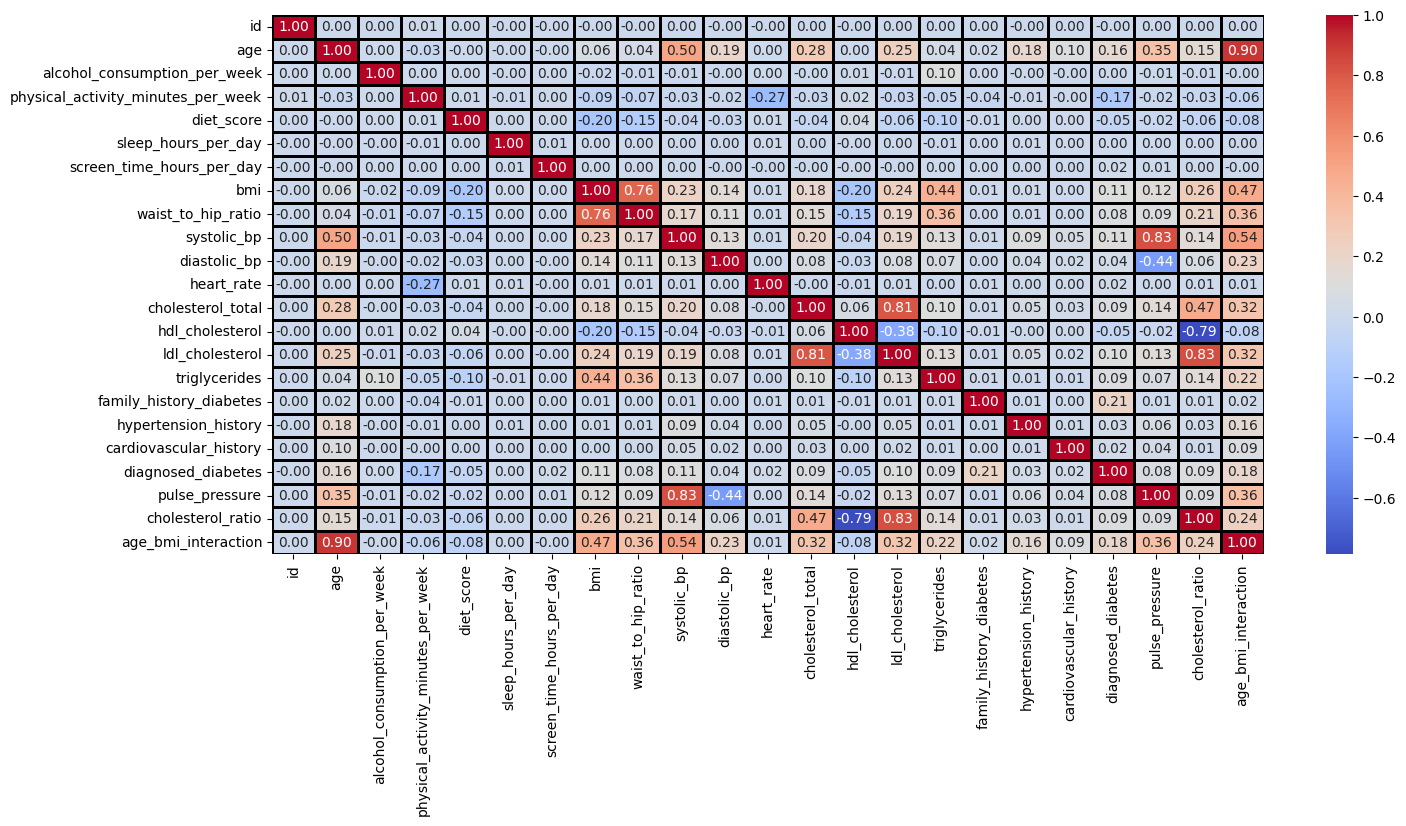

In [21]:
train['pulse_pressure']=train['systolic_bp']-train['diastolic_bp']
test['pulse_pressure']=test['systolic_bp']-test['diastolic_bp']

train ['cholesterol_ratio']=train['ldl_cholesterol']/train['hdl_cholesterol']
test['cholesterol_ratio'] = test['ldl_cholesterol'] / test['hdl_cholesterol']

train['age_bmi_interaction'] = train['age'] * train['bmi']
test['age_bmi_interaction'] = test['age'] * test['bmi']

figsize=plt.figure(figsize=(16,7))
sns.heatmap(train.corr(numeric_only=True), annot= True , cmap= 'coolwarm', linewidth=1, linecolor='black',fmt='.2f')
plt.title=('Corelation Heatmap')

In [12]:
object_cols

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status']

In [13]:
unique_values()

unique values  : in GENDER

 gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
unique values  : in ETHNICITY

 ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
unique values  : in EDUCATION_LEVEL

 education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
unique values  : in INCOME_LEVEL

 income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64
unique values  : in SMOKING_STATUS

 smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64
unique values  : in EMPLOYMENT_STATUS

 employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


In [14]:
OneHotCols = ['gender' , 'ethnicity' , 'employment_status']
OrdinalCols = ['education_level' , 'income_level' , 'smoking_status']

education_order = ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
income_order = ['Low' ,'Lower-Middle' , 'Middle' , 'Upper-Middle' , 'High']
smoking_order = ['Never' , 'Former' , 'Current']

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder

In [16]:
transformer = ColumnTransformer(transformers=[
    ('OneHot' , OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False) , OneHotCols),

    ('Ordinal' , OrdinalEncoder(dtype = int , categories = [education_order , income_order , smoking_order]) , OrdinalCols)

] , remainder = 'passthrough' , verbose_feature_names_out = False)

transformer.set_output(transform = 'pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('OneHot',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'ethnicity', 'employment_status']),
                                ('Ordinal',
                                 OrdinalEncoder(categories=[['No formal',
                                                             'Highschool',
                                                             'Graduate',
                                                             'Postgraduate'],
                                                            ['Low',
                                                             'Lower-Middle',
                                                             'Middle',
                                                             'Upper-Middle',
                                                             'High'],
                                                            ['Never', 'Former',
                                                             'Current']],
                                                dtype=<class 'int'>),
                                 ['education_level', 'income_level',
                                  'smoking_status'])],
                  verbose_feature_names_out=False)

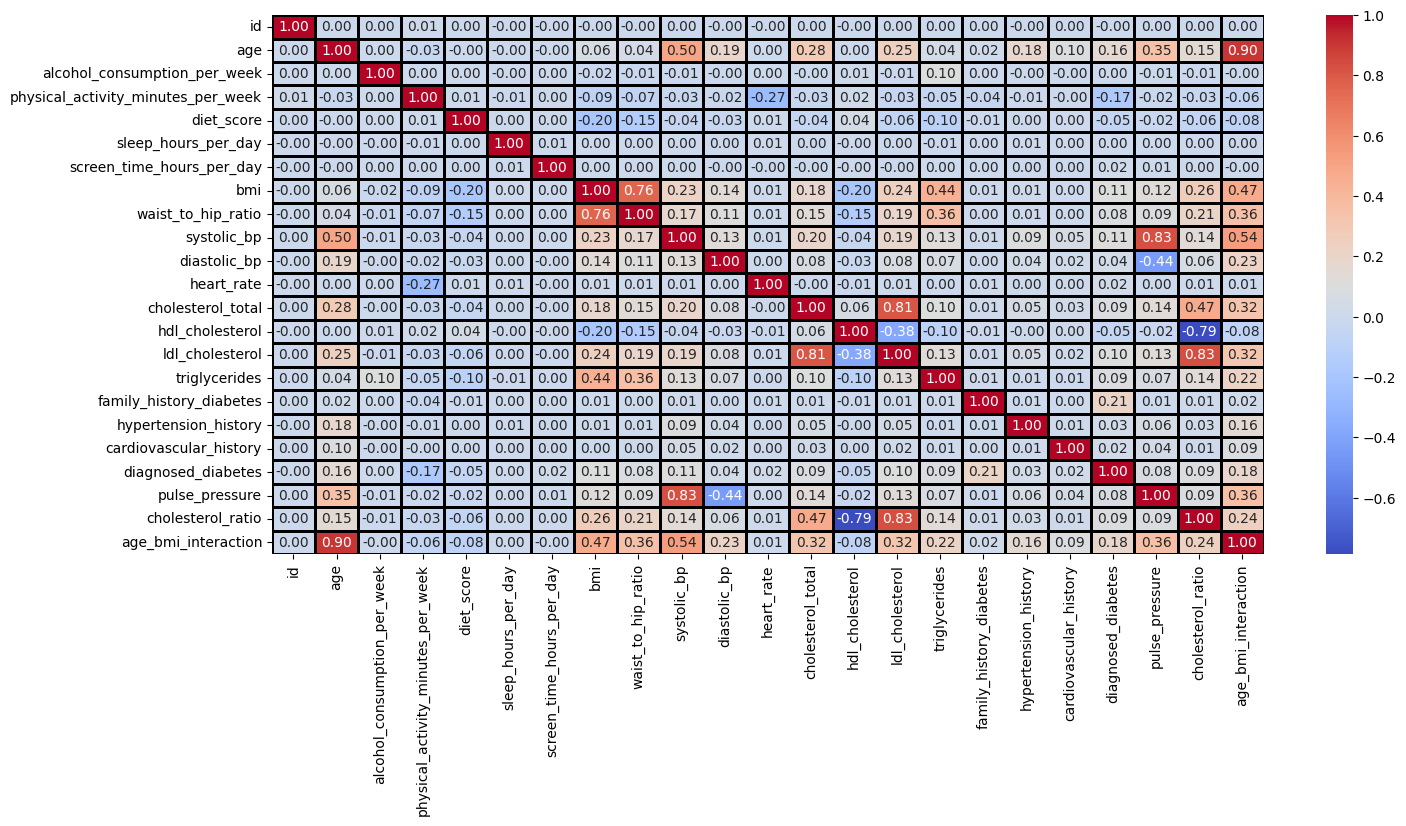

In [20]:
figsize = plt.figure(figsize = (16 , 7))
sns.heatmap(train.corr(numeric_only = True) , annot = True , cmap = 'coolwarm' , linewidth = 1 , linecolor = 'black' , fmt ='.2f' )
plt.title=('Corelation Heatmap')